## Heston 모델 불러오기

In [1]:
"""
V-Guard Option Pricing Engine
=============================
V-Guard = European Call + Volatility Knock-out Barrier

- Barrier check: if realized vol (√v_t) >= vol_barrier at any time → knock-out (payoff = 0)
- Otherwise: payoff = max(S_T - K, 0)
- Price = e^(-rT) × mean(payoffs)

Uses simulate_heston() from src/heston_model.py for path generation.
"""

import os
import sys
import math
import numpy as np


# ── Parameters ──
S0 = 100.0
v0 = 0.04
r = 0.05
lam = 2.0
v_bar = 0.04
eta = 0.3
rho = -0.7
T = 1.0
N_steps = 252
N_paths = 10_000

K_DEFAULT = 100.0
VOL_BARRIER_DEFAULT = 0.30

K_LIST = [90, 95, 100, 105, 110]
BARRIER_LIST = [0.25, 0.30, 0.35, 0.40]


# ── Black-Scholes Reference ──

def _norm_cdf(x):
    """Standard normal CDF using math.erf (no scipy needed)."""
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_call(S, K, r, T, sigma):
    """Black-Scholes European Call price."""
    if sigma <= 0 or T <= 0:
        return max(S - K * math.exp(-r * T), 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * _norm_cdf(d1) - K * math.exp(-r * T) * _norm_cdf(d2)


# ── Pricing Functions ──

def price_vanilla_call(S_paths, r, T, K):
    """
    Vanilla European Call via Monte Carlo.

    Returns: (price, std_error)
    """
    S_T = S_paths[:, -1]
    payoffs = np.maximum(S_T - K, 0.0)
    discount = math.exp(-r * T)
    price = discount * np.mean(payoffs)
    std_error = discount * np.std(payoffs) / math.sqrt(len(payoffs))
    return price, std_error


def price_vguard_call(S_paths, v_paths, r, T, K, vol_barrier):
    """
    V-Guard (Volatility-Barrier Knock-out) Call via Monte Carlo.

    Barrier check: if max(√v_t) along path >= vol_barrier → knock-out
    Payoff: knocked_out ? 0 : max(S_T - K, 0)

    Returns: (price, std_error, ko_rate)
    """
    S_T = S_paths[:, -1]
    vol_paths = np.sqrt(v_paths)
    max_vol = vol_paths.max(axis=1)

    knocked_out = max_vol >= vol_barrier
    ko_rate = knocked_out.mean()

    vanilla_payoffs = np.maximum(S_T - K, 0.0)
    payoffs = np.where(knocked_out, 0.0, vanilla_payoffs)

    discount = math.exp(-r * T)
    price = discount * np.mean(payoffs)
    std_error = discount * np.std(payoffs) / math.sqrt(len(payoffs))

    return price, std_error, ko_rate

In [ ]:
import numpy as np

def simulate_heston(S0, v0, r, lam, v_bar, eta, rho, T, N_steps, N_paths):
    """
    Heston 모델 시뮬레이션 (Milstein Scheme, Log-Price, Reflecting Boundary 적용)
    """
    dt = T / N_steps
    sqrt_dt = np.sqrt(dt)
    
    x_paths = np.zeros((N_paths, N_steps + 1))
    v_paths = np.zeros((N_paths, N_steps + 1))
    
    x_paths[:, 0] = np.log(S0)
    v_paths[:, 0] = v0
    
    Z = np.random.standard_normal((N_paths, N_steps))
    Z_indep = np.random.standard_normal((N_paths, N_steps))
    W = rho * Z + np.sqrt(1.0 - rho**2) * Z_indep
    
    for i in range(N_steps):
        # 이전 스텝에서 절댓값 처리(Reflecting)가 되었으므로 자연스럽게 양수 보장
        v_cur = v_paths[:, i] 
        sqrt_v = np.sqrt(v_cur)

        v_next = (v_cur
                  - lam * (v_cur - v_bar) * dt                 
                  + eta * sqrt_v * sqrt_dt * Z[:, i]           
                  + (eta**2 / 4.0) * dt * (Z[:, i]**2 - 1.0))  
        v_paths[:, i + 1] = np.abs(v_next)
        
        # 2. 로그 주가 경로 업데이트
        x_paths[:, i + 1] = (x_paths[:, i]
                             + (r - v_cur / 2.0) * dt          
                             + sqrt_v * sqrt_dt * W[:, i])     
                             
    S_paths = np.exp(x_paths)
    
    # 이미 모든 v_paths가 절댓값 처리가 되었으므로 그대로 반환
    return S_paths, v_paths

## delta volga 민감성, vega

### 함수

In [3]:
import numpy as np
from scipy.stats import norm

In [4]:
def get_d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

In [5]:
def get_delta(S, K, T, r, q, sigma):
    d1, _ = get_d1_d2(S, K, T, r, q, sigma)
    delta = np.exp(-q * T) * norm.cdf(d1)
    return delta

In [6]:
def get_vega(S, K, T, r, q, sigma):
    d1, _ = get_d1_d2(S, K, T, r, q, sigma)
    d1_prime = norm.pdf(d1)
    vega = S * np.exp(-q * T) * np.sqrt(T) * d1_prime
    return vega

In [7]:
def get_volga(S, K, T, r, q, sigma):
    d1, d2 = get_d1_d2(S, K, T, r, q, sigma)
    vega = get_vega(S, K, T, r, q, sigma)
    volga = vega * (d1 * d2) / sigma
    return volga

In [ ]:
def calculate_greeks_fdm(base_params, K, vol_barrier):
    """
    바닐라 옵션은 사전에 정의된 블랙-숄즈 함수를 사용하고,
    V-Guard 옵션은 유한차분법(FDM)을 이용해 민감도를 산출합니다.
    """
    # 기본 파라미터 추출
    S0 = base_params['S0']
    v0 = base_params['v0']
    T = base_params['T']
    r = base_params['r']
    q = 0.0  # 현재 시뮬레이션에 배당률이 없으므로 0.0 고정
    sigma0 = math.sqrt(v0)
    
    # 🌟 [1] Vanilla 옵션 민감도: 질문자님이 만든 함수 직접 호출 (가장 정확하고 빠름)
    vanilla_delta = get_delta(S0, K, T, r, q, sigma0)
    vanilla_vega = get_vega(S0, K, T, r, q, sigma0)
    vanilla_volga = get_volga(S0, K, T, r, q, sigma0)
    
    # 🌟 [2] V-Guard 옵션 민감도: FDM 방식으로 흔들어서 산출
    h_S = S0 * 0.01       # 주가의 1%
    h_sigma = 0.01        # 변동성의 1% (0.01 포인트)
    
    # Base Price (원래 가격)
    _, vg_base = get_prices_with_seed(**base_params, K=K, vol_barrier=vol_barrier)
    
    # V-Guard Delta 계산 (주가 S0 업)
    params_S_up = base_params.copy()
    params_S_up['S0'] = S0 + h_S
    _, vg_S_up = get_prices_with_seed(**params_S_up, K=K, vol_barrier=vol_barrier)
    
    vg_delta = (vg_S_up - vg_base) / h_S
    
    # V-Guard Vega & Volga 계산 (변동성 sigma0 업/다운)
    params_v_up = base_params.copy()
    params_v_up['v0'] = (sigma0 + h_sigma)**2
    _, vg_v_up = get_prices_with_seed(**params_v_up, K=K, vol_barrier=vol_barrier)
    
    params_v_dn = base_params.copy()
    params_v_dn['v0'] = (sigma0 - h_sigma)**2
    _, vg_v_dn = get_prices_with_seed(**params_v_dn, K=K, vol_barrier=vol_barrier)
    
    vg_vega = (vg_v_up - vg_v_dn) / (2 * h_sigma)
    vg_volga = (vg_v_up - 2 * vg_base + vg_v_dn) / (h_sigma**2)
    
    # 두 결과를 깔끔하게 모아서 반환
    return {
        'vg_delta': vg_delta,
        'vg_vega': vg_vega,
        'vg_volga': vg_volga,
        'vanilla_delta': vanilla_delta,  # 추가됨: 만든 함수 결과
        'vanilla_vega': vanilla_vega,    # FDM 대신 만든 함수 결과 사용
        'vanilla_volga': vanilla_volga   # 추가됨: 만든 함수 결과
    }

In [12]:
import matplotlib.pyplot as plt

def plot_greeks_profiles(base_params, K, vol_barrier):
    """
    주가(S0)와 변동성(sigma0) 변화에 따른 Greeks를 계산하고 그래프로 시각화합니다.
    """
    print("\n[그래프 생성 중...] 델타, 베가, 볼가 프로파일을 계산합니다. (시간이 조금 걸릴 수 있습니다)")
    
    # --- 1. Delta Profile (주가 S0 변화에 따른 델타) ---
    test_S0_list = np.linspace(80, 120, 21) # 주가 80 ~ 120 구간
    delta_list = []
    
    for test_S in test_S0_list:
        test_params = base_params.copy()
        test_params['S0'] = test_S
        greeks = calculate_greeks_fdm(test_params, K, vol_barrier)
        delta_list.append(greeks['vg_delta'])
        
    # --- 2. Vega & Volga Profile (초기 변동성 sigma0 변화에 따른 베가/볼가) ---
    test_sigma_list = np.linspace(0.10, vol_barrier - 0.01, 20) # 변동성 10% ~ 배리어 직전
    vg_vega_list = []
    vg_volga_list = []
    vanilla_vega_list = []
    
    for test_sig in test_sigma_list:
        test_params = base_params.copy()
        test_params['v0'] = test_sig**2 # sigma를 분산(v)으로 변환
        greeks = calculate_greeks_fdm(test_params, K, vol_barrier)
        
        vg_vega_list.append(greeks['vg_vega'])
        vg_volga_list.append(greeks['vg_volga'])
        vanilla_vega_list.append(greeks['vanilla_vega'])

    # --- 3. 그래프 그리기 (시각화) ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 첫 번째 그래프: Delta vs S0
    axes[0].plot(test_S0_list, delta_list, marker='o', color='b', label='V-Guard Delta')
    axes[0].axvline(x=K, color='gray', linestyle='--', label=f'Strike (K={K})')
    axes[0].set_title('Delta Profile (vs S0)')
    axes[0].set_xlabel('Initial Stock Price (S0)')
    axes[0].set_ylabel('Delta')
    axes[0].grid(True)
    axes[0].legend()
    
    # 두 번째 그래프: Vega vs Sigma0 (역전 현상 증명)
    axes[1].plot(test_sigma_list * 100, vanilla_vega_list, marker='s', color='gray', label='Vanilla Vega', alpha=0.6)
    axes[1].plot(test_sigma_list * 100, vg_vega_list, marker='o', color='r', label='V-Guard Vega')
    axes[1].axhline(y=0, color='k', linestyle='-', linewidth=1)
    axes[1].axvline(x=vol_barrier * 100, color='r', linestyle='--', label=f'Barrier ({vol_barrier*100:.0f}%)')
    axes[1].set_title('Vega Profile (vs Initial Volatility)')
    axes[1].set_xlabel('Initial Volatility (%)')
    axes[1].set_ylabel('Vega')
    axes[1].grid(True)
    axes[1].legend()

    # 세 번째 그래프: Volga vs Sigma0
    axes[2].plot(test_sigma_list * 100, vg_volga_list, marker='^', color='g', label='V-Guard Volga')
    axes[2].axhline(y=0, color='k', linestyle='-', linewidth=1)
    axes[2].axvline(x=vol_barrier * 100, color='r', linestyle='--')
    axes[2].set_title('Volga Profile (vs Initial Volatility)')
    axes[2].set_xlabel('Initial Volatility (%)')
    axes[2].set_ylabel('Volga (Rate of Vega change)')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### 결과

  V-Guard Option Pricing & Greeks Engine (Heston FDM + BS)

[1] 기본 환경 Greeks 산출
  [Vanilla] Delta: 0.6368 | Vega(w.r.t sigma): 37.5240 | Volga: 9.8501
  [V-Guard] Delta: 0.5890 | Vega(w.r.t v)    : 1.5993 | Volga: -18238.4403

[Risk Profile] 초기 변동성 증가에 따른 Vega 변화 (Barrier = 30%)
초기 변동성          | Vanilla Vega (BS) | V-Guard Vega (FDM)
-------------------------------------------------------
      10.0%     |         34.2944   |         31.0653
      12.0%     |         35.6100   |         24.9502
      14.0%     |         36.4159   |         20.1553
      16.0%     |         36.9366   |         11.6904
      18.0%     |         37.2854   |         10.3193
      20.0%     |         37.5240   |          1.5993
      22.0%     |         37.6885   |        -18.7422
      24.0%     |         37.8008   |        -99.9533
      26.0%     |         37.8750   |       -127.2996
      28.0%     |         37.9203   |       -255.8182

[그래프 생성 중...] 델타, 베가, 볼가 프로파일을 시각화합니다.


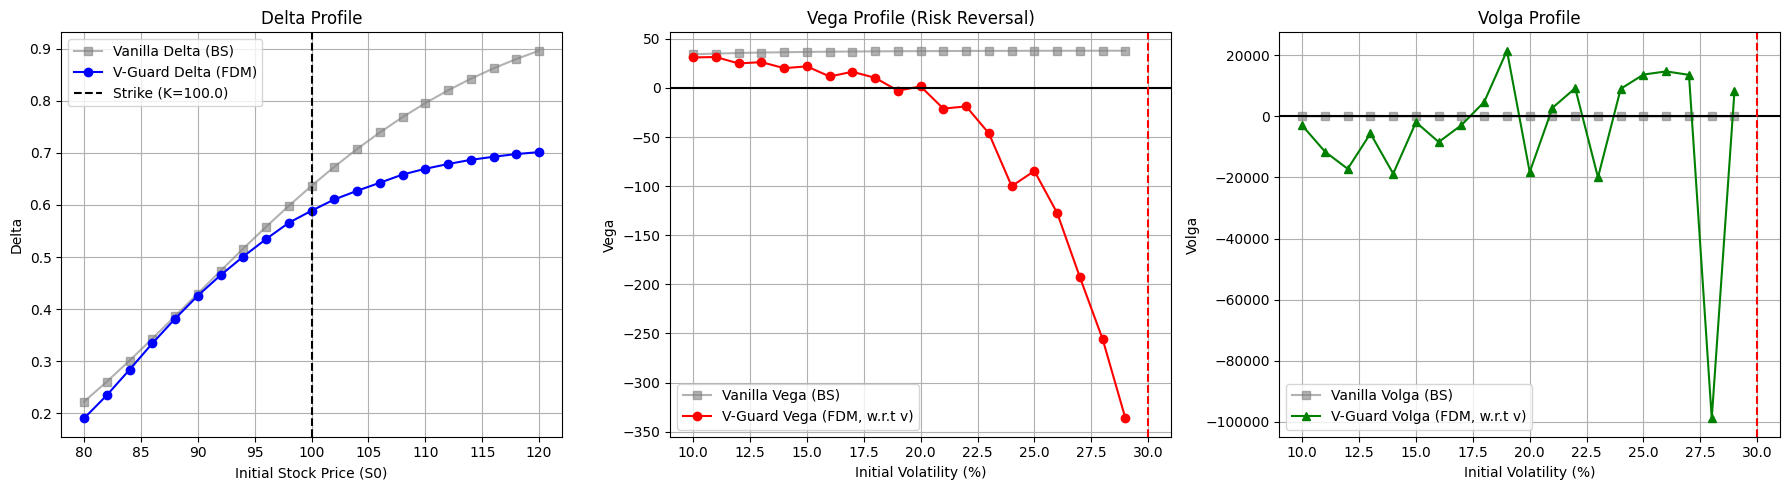

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# ==========================================
# 1. 시뮬레이션 파라미터 설정
# ==========================================
S0 = 100.0
v0 = 0.04
r = 0.05
lam = 2.0
v_bar = 0.04
eta = 0.3
rho = -0.7
T = 1.0
N_steps = 252
N_paths = 10000
K_DEFAULT = 100.0
VOL_BARRIER_DEFAULT = 0.30
# ==========================================
# 2. Black-Scholes 해석적 모델 (Vanilla 대조군용)
# ==========================================
def get_d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def get_delta(S, K, T, r, q, sigma):
    d1, _ = get_d1_d2(S, K, T, r, q, sigma)
    return np.exp(-q * T) * norm.cdf(d1)

def get_vega(S, K, T, r, q, sigma):
    d1, _ = get_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1)

def get_volga(S, K, T, r, q, sigma):
    d1, d2 = get_d1_d2(S, K, T, r, q, sigma)
    vega = get_vega(S, K, T, r, q, sigma)
    return vega * (d1 * d2) / sigma

# ==========================================
# 3. Heston 모델 기반 시뮬레이션 엔진
# ==========================================

def simulate_heston(S0, v0, r, lam, v_bar, eta, rho, T, N_steps, N_paths):
    dt = T / N_steps
    sqrt_dt = np.sqrt(dt)
    x_paths = np.zeros((N_paths, N_steps + 1))
    v_paths = np.zeros((N_paths, N_steps + 1))
    x_paths[:, 0] = np.log(S0)
    v_paths[:, 0] = v0
    Z = np.random.standard_normal((N_paths, N_steps))
    Z_indep = np.random.standard_normal((N_paths, N_steps))
    W = rho * Z + np.sqrt(1.0 - rho**2) * Z_indep
    for i in range(N_steps):
        v_cur = v_paths[:, i]
        sqrt_v = np.sqrt(v_cur)       
        # 분산 경로 (Milstein 보정 + Reflecting Boundary 적용)
        v_next = (v_cur
                  - lam * (v_cur - v_bar) * dt                
                  + eta * sqrt_v * sqrt_dt * Z[:, i]          
                  + (eta**2 / 4.0) * dt * (Z[:, i]**2 - 1.0))  
        v_paths[:, i + 1] = np.abs(v_next)       
        # 로그 주가 경로
        x_paths[:, i + 1] = (x_paths[:, i]
                             + (r - v_cur / 2.0) * dt          
                             + sqrt_v * sqrt_dt * W[:, i])                                 
    return np.exp(x_paths), v_paths



def price_vanilla_call(S_paths, r, T, K):
    S_T = S_paths[:, -1]
    payoffs = np.maximum(S_T - K, 0.0)
    discount = math.exp(-r * T)
    price = discount * np.mean(payoffs)
    std_error = discount * np.std(payoffs) / math.sqrt(len(payoffs))
    return price, std_error



def price_vguard_call(S_paths, v_paths, r, T, K, vol_barrier):
    S_T = S_paths[:, -1]
    vol_paths = np.sqrt(v_paths)
    max_vol = vol_paths.max(axis=1)
    knocked_out = max_vol >= vol_barrier
    ko_rate = knocked_out.mean()
    vanilla_payoffs = np.maximum(S_T - K, 0.0)
    payoffs = np.where(knocked_out, 0.0, vanilla_payoffs)
    discount = math.exp(-r * T)
    price = discount * np.mean(payoffs)
    std_error = discount * np.std(payoffs) / math.sqrt(len(payoffs))
    return price, std_error, ko_rate



def get_prices_with_seed(S0, v0, r, lam, v_bar, eta, rho, T, N_steps, N_paths, K, vol_barrier, seed=42):
    np.random.seed(seed)
    S_paths, v_paths = simulate_heston(S0, v0, r, lam, v_bar, eta, rho, T, N_steps, N_paths)
    return price_vanilla_call(S_paths, r, T, K), price_vguard_call(S_paths, v_paths, r, T, K, vol_barrier)



# =========================================
# 4. Greeks 산출
# ==========================================

def calculate_greeks(base_params, K, vol_barrier):
    S0, v0, T, r = base_params['S0'], base_params['v0'], base_params['T'], base_params['r']
    sigma0 = math.sqrt(v0)   
    # [A] Vanilla
    vanilla_delta = get_delta(S0, K, T, r, 0.0, sigma0)
    vanilla_vega = get_vega(S0, K, T, r, 0.0, sigma0)
    vanilla_volga = get_volga(S0, K, T, r, 0.0, sigma0)
    # [B] V-Guard
    h_S = S0 * 0.01  # 주가 1% 흔들기
    h_v = 0.001      # 분산 v0 흔들   
    # 원래 가격
    _, vg_base_info = get_prices_with_seed(**base_params, K=K, vol_barrier=vol_barrier)
    vg_base = vg_base_info[0]   
    # 1. Delta
    p_S_up = base_params.copy(); p_S_up['S0'] = S0 + h_S
    _, vg_S_up_info = get_prices_with_seed(**p_S_up, K=K, vol_barrier=vol_barrier)
    vg_S_up = vg_S_up_info[0]
    vg_delta = (vg_S_up - vg_base) / h_S

    # 2. Vega & Volga
    p_v_up = base_params.copy(); p_v_up['v0'] = v0 + h_v
    _, vg_v_up_info = get_prices_with_seed(**p_v_up, K=K, vol_barrier=vol_barrier)
    vg_v_up = vg_v_up_info[0]

    p_v_dn = base_params.copy(); p_v_dn['v0'] = v0 - h_v
    _, vg_v_dn_info = get_prices_with_seed(**p_v_dn, K=K, vol_barrier=vol_barrier)
    vg_v_dn = vg_v_dn_info[0]

    # 분산(v0) 기준 민감도 계산
    vg_vega = (vg_v_up - vg_v_dn) / (2 * h_v)
    vg_volga = (vg_v_up - 2 * vg_base + vg_v_dn) / (h_v**2)  

    return {
        'vanilla_delta': vanilla_delta, 'vanilla_vega': vanilla_vega, 'vanilla_volga': vanilla_volga,
        'vg_delta': vg_delta, 'vg_vega': vg_vega, 'vg_volga': vg_volga
    }



# ==========================================

# 5. 프로파일 분석 및 시각화 도구

# ==========================================

def run_risk_profile(base_params, K, vol_barrier):
    print(f"\n[Risk Profile] 초기 변동성 증가에 따른 Vega 변화 (Barrier = {vol_barrier*100:.0f}%)")
    print(f"{'초기 변동성':<15} | {'Vanilla Vega (BS)':<17} | {'V-Guard Vega (FDM)':<17}")
    print("-" * 55)
    for sig in np.arange(0.10, vol_barrier - 0.01, 0.02):
        params = base_params.copy(); params['v0'] = sig**2
        g = calculate_greeks(params, K, vol_barrier)
        print(f"{sig*100:>10.1f}%     | {g['vanilla_vega']:>15.4f}   | {g['vg_vega']:>15.4f}")



def plot_greeks_profiles(base_params, K, vol_barrier):
    print("\n[그래프 생성 중...] 델타, 베가, 볼가 프로파일을 시각화합니다.")
    S_list = np.linspace(80, 120, 21)
    vg_deltas, v_deltas = [], []
    for S in S_list:
        p = base_params.copy(); p['S0'] = S
        g = calculate_greeks(p, K, vol_barrier)
        vg_deltas.append(g['vg_delta']); v_deltas.append(g['vanilla_delta'])
    sig_list = np.linspace(0.10, vol_barrier - 0.01, 20)
    vg_vegas, vg_volgas, v_vegas, v_volgas = [], [], [], []
    for sig in sig_list:
        p = base_params.copy(); p['v0'] = sig**2
        g = calculate_greeks(p, K, vol_barrier)
        vg_vegas.append(g['vg_vega']); vg_volgas.append(g['vg_volga'])
        v_vegas.append(g['vanilla_vega']); v_volgas.append(g['vanilla_volga'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Delta Plot
    axes[0].plot(S_list, v_deltas, 's-', color='gray', label='Vanilla Delta (BS)', alpha=0.6)
    axes[0].plot(S_list, vg_deltas, 'o-', color='b', label='V-Guard Delta (FDM)')
    axes[0].axvline(x=K, color='k', linestyle='--', label=f'Strike (K={K})')
    axes[0].set(title='Delta Profile', xlabel='Initial Stock Price (S0)', ylabel='Delta')
    axes[0].grid(True); axes[0].legend()

   

    # Vega Plot
    axes[1].plot(sig_list*100, v_vegas, 's-', color='gray', label='Vanilla Vega (BS)', alpha=0.6)
    axes[1].plot(sig_list*100, vg_vegas, 'o-', color='r', label='V-Guard Vega (FDM, w.r.t v)')
    axes[1].axhline(y=0, color='k', linestyle='-'); axes[1].axvline(x=vol_barrier*100, color='r', linestyle='--')
    axes[1].set(title='Vega Profile (Risk Reversal)', xlabel='Initial Volatility (%)', ylabel='Vega')
    axes[1].grid(True); axes[1].legend()



    # Volga Plot

    axes[2].plot(sig_list*100, v_volgas, 's-', color='gray', label='Vanilla Volga (BS)', alpha=0.6)
    axes[2].plot(sig_list*100, vg_volgas, '^-', color='g', label='V-Guard Volga (FDM, w.r.t v)')
    axes[2].axhline(y=0, color='k', linestyle='-'); axes[2].axvline(x=vol_barrier*100, color='r', linestyle='--')
    axes[2].set(title='Volga Profile', xlabel='Initial Volatility (%)', ylabel='Volga')
    axes[2].grid(True); axes[2].legend()

    plt.tight_layout(); plt.show()



# ==========================================

# 6. 메인 실행 (Main Execution)

# ==========================================

if __name__ == "__main__":
    base_params = {
        'S0': S0, 'v0': v0, 'r': r, 'lam': lam, 'v_bar': v_bar,
        'eta': eta, 'rho': rho, 'T': T, 'N_steps': N_steps, 'N_paths': N_paths
    }

    print("=" * 65)
    print("  V-Guard Option Pricing & Greeks Engine (Heston FDM + BS)")
    print("=" * 65)

    print("\n[1] 기본 환경 Greeks 산출")
    g_res = calculate_greeks(base_params, K_DEFAULT, VOL_BARRIER_DEFAULT)
    print(f"  [Vanilla] Delta: {g_res['vanilla_delta']:.4f} | Vega(w.r.t sigma): {g_res['vanilla_vega']:.4f} | Volga: {g_res['vanilla_volga']:.4f}")
    print(f"  [V-Guard] Delta: {g_res['vg_delta']:.4f} | Vega(w.r.t v)    : {g_res['vg_vega']:.4f} | Volga: {g_res['vg_volga']:.4f}")

    # Risk Profile 표 출력
    run_risk_profile(base_params, K_DEFAULT, VOL_BARRIER_DEFAULT)
    # 3개의 비교 그래프 출력
    plot_greeks_profiles(base_params, K_DEFAULT, VOL_BARRIER_DEFAULT)